# CAPSTONE TWO
## Sales Analysis of Massachusetts and New Jersey

In [102]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
import sklearn as sk
store_sales = pd.read_csv('Capstone_2_Files/StoreSales.csv')
store_detail = pd.read_csv('Capstone_2_Files/StoreDetail.csv')
products = pd.read_csv('Capstone_2_Files/Products.csv')
product_categories = pd.read_csv('Capstone_2_Files/ProductCategories.csv')
customer_list = pd.read_csv('Capstone_2_Files/customer_list.csv', sep="|")

## Core Marketing Analysis
### QUESTION ONE

In [14]:
territory_storez = store_detail[
    (store_detail['State'] == 'Massachusetts') | 
    (store_detail['State'] == 'New Jersey')
]

# Display ID, City, State, and Manager Name
territory_storez[['Store ID', 'Store Location', 'State', 'Territory Manager']]

,Store ID,Store Location,State,Territory Manager
52,730,Boston,Massachusetts,Bo Heap
53,801,Attleboro,Massachusetts,Bo Heap
54,802,Falmouth,Massachusetts,Bo Heap
55,803,Framingham,Massachusetts,Bo Heap
56,804,Haverhill,Massachusetts,Bo Heap
57,805,Hingham,Massachusetts,Bo Heap
58,806,Holyoke,Massachusetts,Bo Heap
59,807,Leominster,Massachusetts,Bo Heap
60,808,Lowell,Massachusetts,Bo Heap
61,809,Lynn,Massachusetts,Bo Heap


## Monthly Revenue
### QUESTION TWO

In [22]:
# Sales by month using datetime functions
store_sales['Month'] = pd.to_datetime(store_sales['Transaction Date']).dt.to_period('M')
# Merging sales info from new jersey to mass
merged = store_sales.merge(store_detail[store_detail['State'].isin(['New Jersey', 'Massachusetts'])], on='Store ID')
# Results of the merger
result = merged.groupby(['Month', 'State', 'Territory Manager'])['Sale Amount'].sum().round(2)
print(result.to_string())


Month    State          Territory Manager
2022-01  Massachusetts  Bo Heap               69396.42
         New Jersey     Miami Vue             70597.51
2022-02  Massachusetts  Bo Heap               65616.00
         New Jersey     Miami Vue             63225.69
2022-03  Massachusetts  Bo Heap               77390.00
         New Jersey     Miami Vue             64779.71
2022-04  Massachusetts  Bo Heap               81333.60
         New Jersey     Miami Vue             78465.40
2022-05  Massachusetts  Bo Heap               75919.64
         New Jersey     Miami Vue             73037.02
2022-06  Massachusetts  Bo Heap               81227.82
         New Jersey     Miami Vue             66868.55
2022-07  Massachusetts  Bo Heap               67271.23
         New Jersey     Miami Vue             72096.47
2022-08  Massachusetts  Bo Heap               73543.48
         New Jersey     Miami Vue             73904.91
2022-09  Massachusetts  Bo Heap               58716.74
         New Jersey    

In [31]:
#Sum of each state
print("SALES TOTALS BY STATE")
print("~~~~~~~~~~~~~~~~~~~")
region_sum = merged.groupby('State')['Sale Amount'].sum().round(2)
print(region_sum.apply(lambda x: f"{x:,.2f}")) # FORMATTING TO ADD COMMAS

SALES TOTALS BY STATE
~~~~~~~~~~~~~~~~~~~
State
Massachusetts    5,733,256.27
New Jersey       5,175,405.87
Name: Sale Amount, dtype: object


#### RANKING OF MASSACHUSETTS AND NEW JERSEY

In [37]:
# Ranked Massachusetts and New Jersey
ranked = (
    merged.groupby(['State', 'Store ID', 'Store Location'])['Sale Amount']
    .sum().round(2)
    .reset_index()
    .sort_values(['State', 'Sale Amount'], ascending=[True, False])
)

ranked['Rank'] = ranked.groupby('State')['Sale Amount'].rank(ascending=False, method='first').astype(int)

print(ranked[['State', 'Rank', 'Store ID', 'Store Location', 'Sale Amount']].to_string(index=False))

        State  Rank  Store ID Store Location  Sale Amount
Massachusetts     1       817      Worcester    602183.44
Massachusetts     2       807     Leominster    338009.10
Massachusetts     3       810      Nantucket    335547.81
Massachusetts     4       814   Provincetown    328860.51
Massachusetts     5       812    Northampton    322039.24
Massachusetts     6       806        Holyoke    320516.53
Massachusetts     7       816     Somerville    312873.59
Massachusetts     8       804      Haverhill    305762.60
Massachusetts     9       809           Lynn    302049.65
Massachusetts    10       813     Pittsfield    301281.50
Massachusetts    11       811    New Bedford    295443.42
Massachusetts    12       730         Boston    295201.29
Massachusetts    13       801      Attleboro    290883.71
Massachusetts    14       805        Hingham    289633.52
Massachusetts    15       815         Quincy    279646.07
Massachusetts    16       802       Falmouth    276965.55
Massachusetts 

### TOP STORE IN NEW JERSEY: Newark
#### Newark has the highest population in New Jersey, which reflects in the higher sales.
### TOP STORE IN MASSACHUSETTS: Worcester
#### While Worcester isn't the wealthiest or most populus city in Massachusetts, it is closer to the center of the state which may bring more traffic from the surrounding area.
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~

In [40]:
# TOP 5 PERFORMERS FOR EACH REGION
top5 = ranked[ranked['Rank'] <= 5]
print(top5)

            State  Store ID Store Location  Sale Amount  Rank
17  Massachusetts       817      Worcester    602183.44     1
7   Massachusetts       807     Leominster    338009.10     2
10  Massachusetts       810      Nantucket    335547.81     3
14  Massachusetts       814   Provincetown    328860.51     4
12  Massachusetts       812    Northampton    322039.24     5
29     New Jersey       835         Newark    623163.53     1
32     New Jersey       838        Trenton    597565.68     2
24     New Jersey       830        Hoboken    316775.48     3
18     New Jersey       824  Atlantic City    314513.77     4
28     New Jersey       834  New Brunswick    311056.42     5


#### Top Performers:
##### MASSACHUSETTS STORE (817)
##### NEW JERSEY STORE (835)

## Top Customers
### QUESTION FOUR


In [20]:
merged = (
    store_sales.dropna(subset=["RewardsID"])
    .merge(store_detail[store_detail["State"].isin(["Massachusetts", "New Jersey"])], on="Store ID")
    .merge(customer_list, left_on="RewardsID", right_on='cust_id')
    .groupby(["State", "Territory Manager", "name"])["Sale Amount"].sum()
    .reset_index()
    .sort_values("Sale Amount", ascending=False)
    .groupby("Territory Manager")
    .first()
    .reset_index()[["State", "name", "Sale Amount"]]
)
 
print(merged.to_string(index=False))

        State            name  Sale Amount
Massachusetts Beverly Crusher      4758.92
   New Jersey       Gus Fring      5005.07


##### Beverly Crusher was the top customer for Massachusetts 

##### Gus Fring was the top customer for New Jersey

In [50]:
# Monthly sales
store_sales['Transaction Date'] = pd.to_datetime(store_sales['Transaction Date'])
store_sales['Month'] = store_sales['Transaction Date'].dt.to_period('M').astype(str)
# Joining data
df = (
    store_sales
        .merge(products, on='Prod Num', how='left') \
        .merge(store_detail[['Store ID', 'Region']], on='Store ID', how='left')
        .merge(product_categories[['CategoryID', 'Category']], on='CategoryID', how='left')
)
# Category and territory
transactions = (
    df.groupby(['Month', 'Region', 'CategoryID', 'Category'])
      .size()
      .reset_index(name='Transaction_Count')
)
# Revenue by category
revenue = (
    df.groupby(['Month', 'Category'])['Sale Amount']
      .sum()
      .reset_index(name='Total_Revenue')
)


### QUESTION FIVE

In [53]:
# Print statements
print("\n TOTAL TRANSACTIONS")
print(transactions)
print("\n TOTAL REVENUE")
print(revenue)


 TOTAL TRANSACTIONS
        Month Region                  Category  Transaction_Count
0     2022-01   East   Apparel and Merchandise                864
1     2022-01   East              Art Supplies                880
2     2022-01   East           Books (General)                172
3     2022-01   East   Stationery and Supplies               1210
4     2022-01   East  Technology & Accessories                826
...       ...    ...                       ...                ...
1147  2025-12   West              Art Supplies               2618
1148  2025-12   West           Books (General)                408
1149  2025-12   West   Stationery and Supplies               3223
1150  2025-12   West  Technology & Accessories               2408
1151  2025-12   West                 Textbooks               1969

[1152 rows x 4 columns]

 TOTAL REVENUE
       Month                  Category  Total_Revenue
0    2022-01   Apparel and Merchandise      208993.12
1    2022-01              Art Supplies

In [54]:
# Exporting CSV for Analysis
transactions.to_csv("transactions_output.csv", index=False)
revenue.to_csv("revenue_output.csv", index=False)


#### Analysis of Transactions and Revenue
The Northeast region shows a strong demand particularly driven by a high ticket items such as Technology & Accessories. From 2022 to 2025, sales in categories such as Stationary & Supplies have grown dramatically, from 5,300 monthly sales to over 16,000. This represents a returning customer base with a pension for specific items sold by Emporium.

Our opportunities for growth revolve around optimizing our lower ticket sales by bundling them with higher ticket items to increase revenue per transaction. Seasonal spikes over the years reveal an opportunity to roll out promotional campaigns that will further drive growth in the region
### Recommendation
I recommend focusing on maximizing our most popular (lower ticket) items. Because the demand is so high for these specific products, it will be easier to bundle other products to capitalize on buyer behaviour. In addition to maximizing our lower ticket items, we can offer accessory bundles with Technology purchases to boost average revenue per order.

### CHART ONE

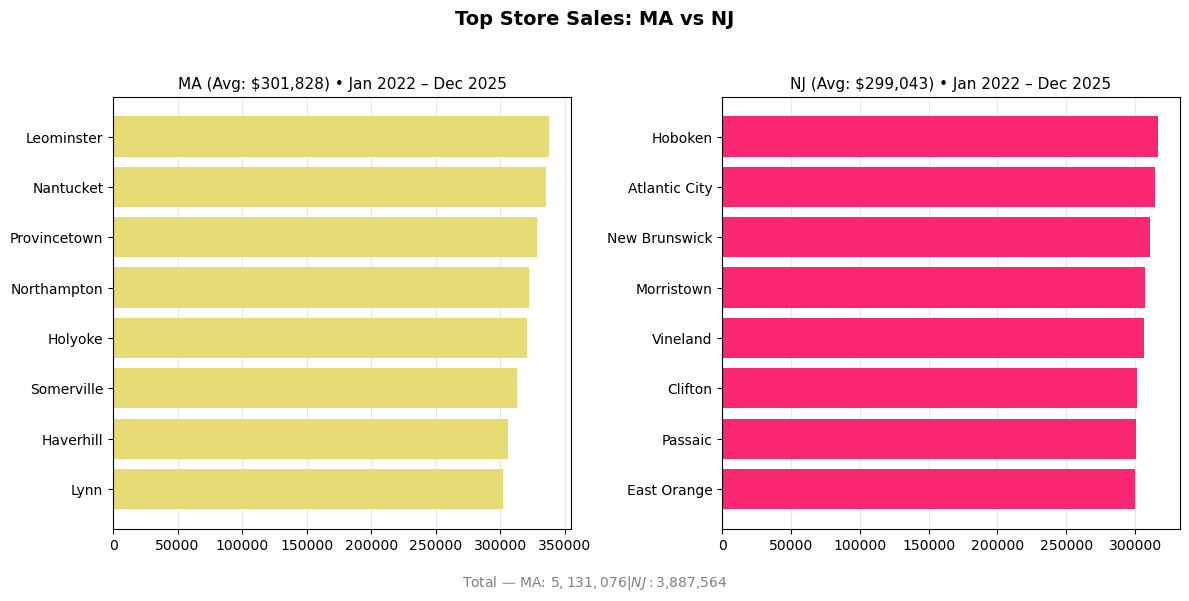

In [101]:
# Data 
MA = [
    ("Worcester",602183), ("Leominster",338009), ("Nantucket",335548),
    ("Provincetown",328861), ("Northampton",322039), ("Holyoke",320517),
    ("Somerville",312874), ("Haverhill",305763), ("Lynn",302050),
    ("Pittsfield",301282), ("New Bedford",295443), ("Boston",295201),
    ("Attleboro",290884), ("Hingham",289634), ("Quincy",279646),
    ("Falmouth",276966), ("Framingham",269376), ("Lowell",266983),
]

NJ = [
    ("Newark",623164), ("Trenton",597566), ("Hoboken",316775),
    ("Atlantic City",314514), ("New Brunswick",311056), ("Morristown",307321),
    ("Vineland",306326), ("Clifton",301704), ("Passaic",300359),
    ("East Orange",299936), ("Jersey City",296244), ("Hackensack",293677),
    ("Bayonne",292354), ("Cape May",285705), ("Montclair",261593),
    ("Paterson",67113),
]

# Clean data
def clean(data):
    v = np.array([x[1] for x in data])
    m, s = v.mean(), v.std()
    return [(n, val) for n, val in data if abs(val - m) <= 1.5*s]

MA, NJ = clean(MA), clean(NJ)

# Helper functions
def stats(values):
    return sum(values), np.mean(values)

def top8(data):
    return zip(*sorted(data, key=lambda x: x[1], reverse=True)[:8])

# Prep 
ma_names, ma_vals = zip(*MA)
nj_names, nj_vals = zip(*NJ)

ma_total, ma_avg = stats(ma_vals)
nj_total, nj_avg = stats(nj_vals)

# Plot layout
fig, ax = plt.subplots(1, 2, figsize=(12, 6))
fig.suptitle("Top Store Sales: MA vs NJ", fontsize=14, fontweight="bold")

# Style 
MA_COL, NJ_COL = "#E6DB74", "#F92672"

def draw(ax, data, title, color):
    names, vals = top8(data)
    ax.barh(names, vals, color=color)
    ax.set_title(title, fontsize=11)
    ax.invert_yaxis()
    ax.grid(axis="x", alpha=0.3)
    ax.set_axisbelow(True)

# Charts
start = df["Transaction Date"].min()
end   = df["Transaction Date"].max()

timeframe = f"{start:%b %Y} – {end:%b %Y}"

draw(ax[0], MA, f"MA (Avg: ${ma_avg:,.0f}) • {timeframe}", MA_COL)
draw(ax[1], NJ, f"NJ (Avg: ${nj_avg:,.0f}) • {timeframe}", NJ_COL)


# Footer stats
fig.text(0.5, 0.02,
         f"Total — MA: ${ma_total:,.0f} | NJ: ${nj_total:,.0f}",
         ha="center", fontsize=10, color="gray")

plt.tight_layout(rect=[0, 0.05, 1, 0.95])
plt.show()


### CHART TWO

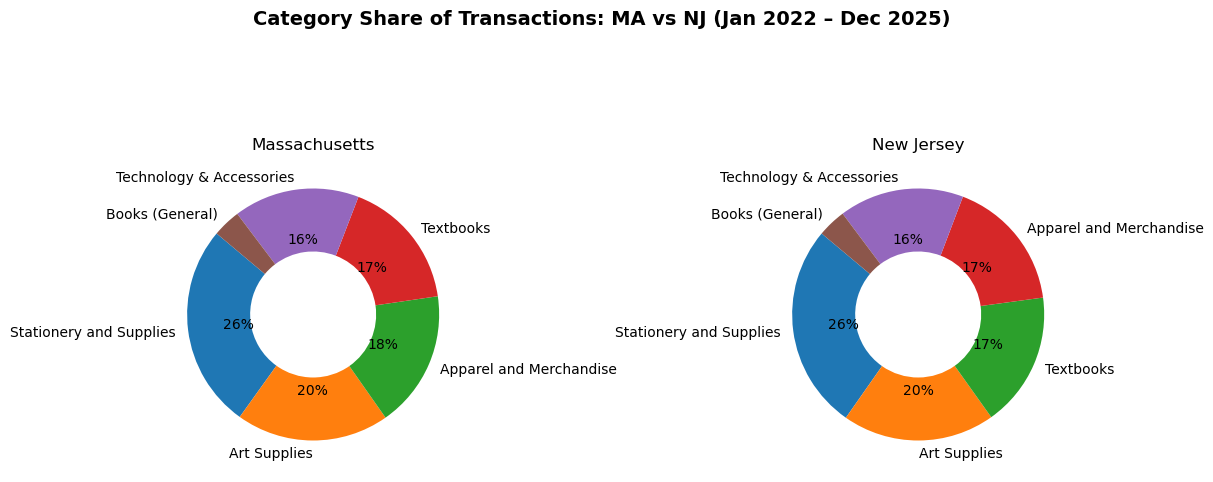

In [118]:

# Aggregate Transactions
summary = (
    df.groupby(["State", "Category"])
    .size()
    .reset_index(name="Transactions")
)

# Plot 
fig, ax = plt.subplots(1, 2, figsize=(12, 6))
fig.suptitle(
    f"Category Share of Transactions: MA vs NJ ({timeframe})",
    fontsize=14,
    fontweight="bold"
)

def plot_state(axis, state, color):
    data = summary[summary["State"] == state] \
        .sort_values("Transactions", ascending=False).head(6)

    values = data["Transactions"]
    labels = data["Category"]

    wedges, texts, autotexts = axis.pie(
        values,
        labels=labels,
        autopct=lambda p: f"{p:.0f}%" if p > 5 else "",
        startangle=140,
        wedgeprops=dict(width=0.5)  # makes it a donut
    )

    axis.set_title(state)

plot_state(ax[0], "Massachusetts", "#E6DB74")
plot_state(ax[1], "New Jersey", "#F92672")

plt.tight_layout()
plt.show()
